##### *Copyright 2020 Google LLC*
*Licensed under the Apache License, Version 2.0 (the "License")*

In [1]:
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Retrain a classification model for Edge TPU using post-training quantization (with TF2)

In this tutorial, we'll use TensorFlow 2 to create an image classification model, train it with a flowers dataset, and convert it to TensorFlow Lite using post-training quantization. Finally, we compile it for compatibility with the Edge TPU (available in [Coral devices](https://coral.ai/products/)).

The model is based on a pre-trained version of MobileNet V2. We'll start by retraining only the classification layers, reusing MobileNet's pre-trained feature extractor layers. Then we'll fine-tune the model by updating weights in some of the feature extractor layers. This type of transfer learning is much faster than training the entire model from scratch.

Once it's trained, we'll use post-training quantization to convert all parameters to int8 format, which reduces the model size and increases inferencing speed. This format is also required for compatibility on the Edge TPU.

For more information about how to create a model compatible with the Edge TPU, see the [documentation at coral.ai](https://coral.ai/docs/edgetpu/models-intro/).

**Note:** This tutorial requires TensorFlow 2.3+ for full quantization, which currently does not work for all types of models. In particular, this tutorial expects a Keras-built model and this conversion strategy currently doesn't work with models imported from a frozen graph. (If you're using TF 1.x, see [the 1.x version of this tutorial](https://colab.research.google.com/github/google-coral/tutorials/blob/master/retrain_classification_ptq_tf1.ipynb).)

<a href="https://colab.research.google.com/github/google-coral/tutorials/blob/master/retrain_classification_ptq_tf2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"></a>
&nbsp;&nbsp;&nbsp;&nbsp;
<a href="https://github.com/google-coral/tutorials/blob/master/retrain_classification_ptq_tf2.ipynb" target="_parent"><img src="https://img.shields.io/static/v1?logo=GitHub&label=&color=333333&style=flat&message=View%20on%20GitHub" alt="View in GitHub"></a>


To start running all the code in this tutorial, select **Runtime > Run all** in the Colab toolbar.

## Import the required libraries

In order to quantize both the input and output tensors, we need `TFLiteConverter` APIs that are available in TensorFlow r2.3 or higher:

In [2]:
import tensorflow as tf
## assert float(tf.__version__[:3]) >= 2.3 Doesn't work for 2.14.0

import os
import numpy as np
import matplotlib.pyplot as plt

2025-05-26 18:25:55.326866: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-26 18:25:55.755439: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-26 18:25:56.153565: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748276756.521985 2751248 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748276756.641902 2751248 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1748276757.583619 2751248 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

## Prepare the training data

First let's download and organize the flowers dataset we'll use to retrain the model (it contains 5 flower classes).

Pay attention to this part so you can reproduce it with your own images dataset. In particular, notice that the "flower_photos" directory contains an appropriately-named directory for each class. The following code randomizes and divides up the photos into training and validation sets, and generates a labels file based on the photo folder names.

In [3]:
_URL = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

zip_file = tf.keras.utils.get_file(origin=_URL, 
                                   fname="flower_photos.tgz", 
                                   extract=True)

flowers_dir = os.path.join(os.path.dirname(zip_file), 'flower_photos')


Next, we use [`ImageDataGenerator`](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image/ImageDataGenerator) to rescale the image data into float values (divide by 255 so the tensor values are between 0 and 1), and call `flow_from_directory()` to create two generators: one for the training dataset and one for the validation dataset.


In [4]:
IMAGE_SIZE = 224
BATCH_SIZE = 64

datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255, 
    validation_split=0.2)

train_generator = datagen.flow_from_directory(
    flowers_dir,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE, 
    subset='training')

val_generator = datagen.flow_from_directory(
    flowers_dir,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE, 
    subset='validation')

Found 2939 images belonging to 5 classes.
Found 731 images belonging to 5 classes.



On each iteration, these generators provide a batch of images by reading images from disk and processing them to the proper tensor size (224 x 224). The output is a tuple of (images, labels). For example, you can see the shapes here:

In [5]:
image_batch, label_batch = next(val_generator)
image_batch.shape, label_batch.shape

((64, 224, 224, 3), (64, 5))

Now save the class labels to a text file:

In [6]:
print (train_generator.class_indices)

labels = '\n'.join(sorted(train_generator.class_indices.keys()))

with open('flower_labels.txt', 'w') as f:
  f.write(labels)

{'daisy': 0, 'dandelion': 1, 'roses': 2, 'sunflowers': 3, 'tulips': 4}


In [7]:
!cat flower_labels.txt

daisy
dandelion
roses
sunflowers
tulips

## Build the model

Now we'll create a model that's capable of transfer learning on just the last fully-connected layer. 

We'll start with MobileNet V2 from Keras as the base model, which is pre-trained with the ImageNet dataset (trained to recognize 1,000 classes). This provides us a great feature extractor for image classification and we can then train a new classification layer with our flowers dataset.



### Create the base model 

When instantiating the `MobileNetV2` model, we specify the `include_top=False` argument in order to load the network *without* the classification layers at the top. Then we set `trainable` false to freeze all the weights in the base model. This effectively converts the model into a feature extractor because all the pre-trained weights and biases are preserved in the lower layers when we begin training for our classification head.

In [8]:
IMG_SHAPE = (IMAGE_SIZE, IMAGE_SIZE, 3)

# Create the base model from the pre-trained MobileNet V2
base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,
                                              include_top=False, 
                                              weights='imagenet')
base_model.trainable = False

2025-05-26 18:26:43.743555: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


### Add a classification head

Now we create a new [`Sequential`](https://www.tensorflow.org/api_docs/python/tf/keras/Sequential) model and pass the frozen MobileNet model as the base of the graph, and append new classification layers so we can set the final output dimension to match the number of classes in our dataset (5 types of flowers).

In [9]:
model = tf.keras.Sequential([
  base_model,
  tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.GlobalAveragePooling2D(),
  tf.keras.layers.Dense(units=5, activation='softmax')
])

### Configure the model

Although this method is called `compile()`, it's basically a configuration step that's required before we can start training.

In [10]:
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

You can see a string summary of the final network with the `summary()` method:

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 5, 5, 32)       │       368,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,626,821 (10.02 MB)

 Trainable params: 368,837 (1.41 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

And because the majority of the model graph is frozen in the base model, weights from only the last convolution and dense layers are trainable:

In [12]:
print('Number of trainable weights = {}'.format(len(model.trainable_weights)))

Number of trainable weights = 4


## Train the model


Now we can train the model using data provided by the `train_generator` and `val_generator` that we created at the beginning. 

This should take less than 10 minutes.

In [13]:
history = model.fit(train_generator,
                    steps_per_epoch=len(train_generator), 
                    epochs=10,
                    validation_data=val_generator,
                    validation_steps=len(val_generator))

Epoch 1/10


/home/zboucek/anaconda3/envs/tf/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


46/46 ━━━━━━━━━━━━━━━━━━━━ 39s 800ms/step - accuracy: 0.6643 - loss: 1.0728 - val_accuracy: 0.8057 - val_loss: 0.5296
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 36s 777ms/step - accuracy: 0.8968 - loss: 0.2827 - val_accuracy: 0.8577 - val_loss: 0.4072
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 36s 778ms/step - accuracy: 0.9528 - loss: 0.1523 - val_accuracy: 0.8618 - val_loss: 0.3806
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 36s 778ms/step - accuracy: 0.9676 - loss: 0.1026 - val_accuracy: 0.8605 - val_loss: 0.4116
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 36s 777ms/step - accuracy: 0.9816 - loss: 0.0605 - val_accuracy: 0.8673 - val_loss: 0.4110
Epoch 6/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 36s 781ms/step - accuracy: 0.9944 - loss: 0.0370 - val_accuracy: 0.8618 - val_loss: 0.4545
Epoch 7/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 36s 784ms/step - accuracy: 0.9954 - loss: 0.0258 - val_accuracy: 0.8632 - val_loss: 0.4548
Epoch 8/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 36s 779ms/step - accuracy: 0.9961 - loss: 0.0170 - val_accuracy: 0.865

### Review the learning curves


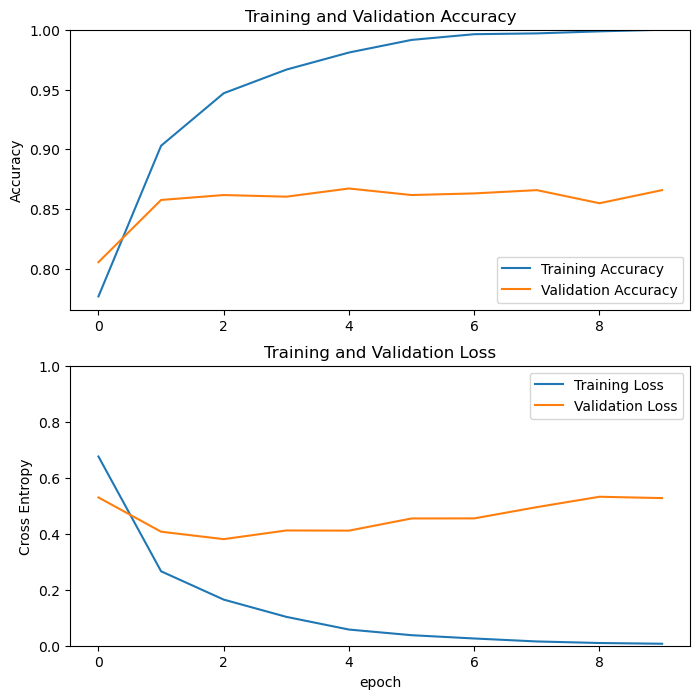

In [14]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

## Fine tune the base model


So far, we've only trained the classification layers—the weights of the pre-trained network were *not* changed.

One way we can increase the accuracy is to train (or "fine-tune") more layers from the pre-trained model. That is, we'll un-freeze some layers from the base model and adjust those weights (which were originally trained with 1,000 ImageNet classes) so they're better tuned for features found in our flowers dataset.

### Un-freeze more layers


So instead of freezing the entire base model, we'll freeze individual layers.

First, let's see how many layers are in the base model:

In [15]:
print("Number of layers in the base model: ", len(base_model.layers))

Number of layers in the base model:  154


Let's try freezing just the bottom 100 layers.

In [16]:
base_model.trainable = True
fine_tune_at = 100

# Freeze all the layers before the `fine_tune_at` layer
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable =  False

### Reconfigure the model

Now configure the model again, but this time with a lower learning rate (the default is 0.001).

In [17]:
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 5, 5, 32)       │       368,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,626,821 (10.02 MB)

 Trainable params: 2,230,277 (8.51 MB)

 Non-trainable params: 396,544 (1.51 MB)

In [19]:
print('Number of trainable weights = {}'.format(len(model.trainable_weights)))

Number of trainable weights = 58


### Continue training

Now let's fine-tune all trainable layers. This starts with the weights we already trained in the classification layers, so we don't need as many epochs.

In [20]:
history_fine = model.fit(train_generator,
                         steps_per_epoch=len(train_generator), 
                         epochs=5,
                         validation_data=val_generator,
                         validation_steps=len(val_generator))

Epoch 1/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.8476 - loss: 0.5064 - val_accuracy: 0.8591 - val_loss: 0.5314
Epoch 2/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.9182 - loss: 0.2222 - val_accuracy: 0.8659 - val_loss: 0.5349
Epoch 3/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.9514 - loss: 0.1294 - val_accuracy: 0.8700 - val_loss: 0.5383
Epoch 4/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.9698 - loss: 0.0959 - val_accuracy: 0.8687 - val_loss: 0.5316
Epoch 5/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.9735 - loss: 0.0722 - val_accuracy: 0.8673 - val_loss: 0.5364


### Review the new learning curves

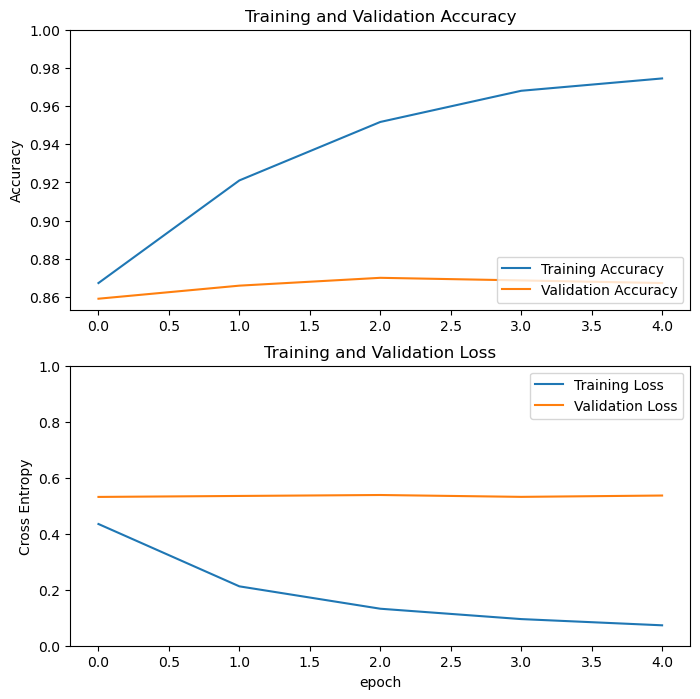

In [21]:
acc = history_fine.history['accuracy']
val_acc = history_fine.history['val_accuracy']

loss = history_fine.history['loss']
val_loss = history_fine.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

This is better, but it's not ideal.

The validation loss is still higher than the training loss, so there could be some overfitting during training. The overfitting might also be because the new training set is relatively small with less intra-class variance, compared to the original ImageNet dataset used to train MobileNet V2.

So this model isn't trained to an accuracy that's production ready, but it works well enough as a demonstration.

Let's move on and convert the model to TensorFlow Lite.

## Convert to TFLite

Ordinarily, creating a TensorFlow Lite model is just a few lines of code with [`TFLiteConverter`](https://www.tensorflow.org/api_docs/python/tf/lite/TFLiteConverter). For example, this creates a basic (un-quantized) TensorFlow Lite model:

In [22]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('mobilenet_v2_1.0_224.tflite', 'wb') as f:
  f.write(tflite_model)

INFO:tensorflow:Assets written to: /tmp/tmpewiruro9/assets


INFO:tensorflow:Assets written to: /tmp/tmpewiruro9/assets


Saved artifact at '/tmp/tmpewiruro9'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  131234828409872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131234828413136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131234828415056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131234828414864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131234828413520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131234828415440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131234828413904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131234828416208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131234828415824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131234828413712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1312348284

W0000 00:00:1748277453.670581 2751248 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1748277453.670597 2751248 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2025-05-26 18:37:33.670960: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpewiruro9
2025-05-26 18:37:33.680430: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-05-26 18:37:33.680441: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpewiruro9
I0000 00:00:1748277453.758813 2751248 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
2025-05-26 18:37:33.773569: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-05-26 18:37:34.253983: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpewiruro9
2025-05-26 18:37:34.387065: I tensorflow/cc/saved_model/loader.cc:471] SavedModel 

However, this `.tflite` file still uses floating-point values for the parameter data, and we need to fully quantize the model to int8 format.

To fully quantize the model, we need to perform [post-training quantization](https://www.tensorflow.org/lite/performance/post_training_quantization) with a representative dataset, which requires a few more arguments for the `TFLiteConverter`, and a function that builds a dataset that's representative of the training dataset. 

So let's convert the model again with post-training quantization:

In [23]:
# A generator that provides a representative dataset
def representative_data_gen():
  dataset_list = tf.data.Dataset.list_files(flowers_dir + '/*/*')
  for i in range(100):
    image = next(iter(dataset_list))
    image = tf.io.read_file(image)
    image = tf.io.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMAGE_SIZE, IMAGE_SIZE])
    image = tf.cast(image / 255., tf.float32)
    image = tf.expand_dims(image, 0)
    yield [image]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
# This enables quantization
converter.optimizations = [tf.lite.Optimize.DEFAULT]
# This sets the representative dataset for quantization
converter.representative_dataset = representative_data_gen
# This ensures that if any ops can't be quantized, the converter throws an error
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
# For full integer quantization, though supported types defaults to int8 only, we explicitly declare it for clarity.
converter.target_spec.supported_types = [tf.int8]
# These set the input and output tensors to uint8 (added in r2.3)
converter.inference_input_type = tf.uint8
converter.inference_output_type = tf.uint8
tflite_model = converter.convert()

with open('mobilenet_v2_1.0_224_quant.tflite', 'wb') as f:
  f.write(tflite_model)

INFO:tensorflow:Assets written to: /tmp/tmp67dcq17v/assets


INFO:tensorflow:Assets written to: /tmp/tmp67dcq17v/assets


Saved artifact at '/tmp/tmp67dcq17v'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  131234828409872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131234828413136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131234828415056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131234828414864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131234828413520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131234828415440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131234828413904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131234828416208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131234828415824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131234828413712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1312348284

/home/zboucek/anaconda3/envs/tf/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1748277459.600540 2751248 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1748277459.600556 2751248 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2025-05-26 18:37:39.600689: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp67dcq17v
2025-05-26 18:37:39.610213: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-05-26 18:37:39.610222: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp67dcq17v
2025-05-26 18:37:39.703729: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-05-26 18:37:40.189722: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: 

### Compare the accuracy


So now we have a fully quantized TensorFlow Lite model. To be sure the conversion went well, let's evaluate both the raw model and the TensorFlow Lite model.

First check the accuracy of the raw model:

In [24]:
batch_images, batch_labels = next(val_generator)

logits = model(batch_images)
prediction = np.argmax(logits, axis=1)
truth = np.argmax(batch_labels, axis=1)

keras_accuracy = tf.keras.metrics.Accuracy()
keras_accuracy(prediction, truth)

print("Raw model accuracy: {:.3%}".format(keras_accuracy.result()))

Raw model accuracy: 85.938%


Now let's check the accuracy of the `.tflite` file, using the same dataset.

However, there's no convenient API to evaluate the accuracy of a TensorFlow Lite model, so this code runs several inferences and compares the predictions against ground truth:

In [25]:
def set_input_tensor(interpreter, input):
  input_details = interpreter.get_input_details()[0]
  tensor_index = input_details['index']
  input_tensor = interpreter.tensor(tensor_index)()[0]
  # Inputs for the TFLite model must be uint8, so we quantize our input data.
  # NOTE: This step is necessary only because we're receiving input data from
  # ImageDataGenerator, which rescaled all image data to float [0,1]. When using
  # bitmap inputs, they're already uint8 [0,255] so this can be replaced with:
  #   input_tensor[:, :] = input
  scale, zero_point = input_details['quantization']
  input_tensor[:, :] = np.uint8(input / scale + zero_point)

def classify_image(interpreter, input):
  set_input_tensor(interpreter, input)
  interpreter.invoke()
  output_details = interpreter.get_output_details()[0]
  output = interpreter.get_tensor(output_details['index'])
  # Outputs from the TFLite model are uint8, so we dequantize the results:
  scale, zero_point = output_details['quantization']
  output = scale * (output - zero_point)
  top_1 = np.argmax(output)
  return top_1

interpreter = tf.lite.Interpreter('mobilenet_v2_1.0_224_quant.tflite')
interpreter.allocate_tensors()

# Collect all inference predictions in a list
batch_prediction = []
batch_truth = np.argmax(batch_labels, axis=1)

for i in range(len(batch_images)):
  prediction = classify_image(interpreter, batch_images[i])
  batch_prediction.append(prediction)

# Compare all predictions to the ground truth
tflite_accuracy = tf.keras.metrics.Accuracy()
tflite_accuracy(batch_prediction, batch_truth)
print("Quant TF Lite accuracy: {:.3%}".format(tflite_accuracy.result()))


/home/zboucek/anaconda3/envs/tf/lib/python3.11/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Quant TF Lite accuracy: 84.375%


You might see some, but hopefully not very much accuracy drop between the raw model and the TensorFlow Lite model. But again, these results are not suitable for production deployment.

## Compile for the Edge TPU


Finally, we're ready to compile the model for the Edge TPU.

First download the [Edge TPU Compiler](https://coral.ai/docs/edgetpu/compiler/):

In [ ]:
! curl https://packages.cloud.google.com/apt/doc/apt-key.gpg | sudo apt-key add -

! echo "deb https://packages.cloud.google.com/apt coral-edgetpu-stable main" | sudo tee /etc/apt/sources.list.d/coral-edgetpu.list

! sudo apt-get update

! sudo apt-get install edgetpu-compiler	

[sudo] password for zboucek:   % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  1022  100  1022    0     0   6648      0 --:--:-- --:--:-- --:--:--  6679

sudo: a password is required
^C
[sudo] password for zboucek: 
sudo: a password is required
^C
[sudo] password for zboucek: 
sudo: a password is required
^C
[sudo] password for zboucek: 

Then compile the model:

In [ ]:
! edgetpu_compiler mobilenet_v2_1.0_224_quant.tflite

That's it.

The compiled model uses the same filename but with "_edgetpu" appended at the end.

## Download the model

You can download the converted model and labels file from Colab like this: 

In [ ]:
from google.colab import files

files.download('mobilenet_v2_1.0_224_quant_edgetpu.tflite')
files.download('flower_labels.txt')

If you get a "Failed to fetch" error here, it's probably because the files weren't done saving. So just wait a moment and try again.

Also look out for a browser popup that might need approval to download the files.

## Run the model on the Edge TPU




You can now run the model on your Coral device with acceleration on the Edge TPU.

To get started, try using your `.tflite` model with [this code for image classification with the TensorFlow Lite API](https://github.com/google-coral/tflite/tree/master/python/examples/classification). 

Just follow the instructions on that page to set up your device, copy the `mobilenet_v2_1.0_224_quant_edgetpu.tflite` and `flower_labels.txt` files to your Coral Dev Board or device with a Coral Accelerator, and pass it a flower photo like this:

```
python3 classify_image.py \
  --model mobilenet_v2_1.0_224_quant_edgetpu.tflite \
  --labels flower_labels.txt \
  --input flower.jpg
```

Check out more examples for running inference at [coral.ai/examples](https://coral.ai/examples/#code-examples/).